# EEG Motor İmgelem Sınıflandırması — v2
## PhysioNet EEG Motor Movement/Imagery Dataset

**Kaynak:** https://www.physionet.org/content/eegmmidb/1.0.0/

**v2 İyileştirmeleri:**
- Özne bazlı (within-subject) eğitim — her denek kendi içinde çapraz doğrulama
- Motor korteks kanalları seçimi (C3, Cz, C4, FC3, FC4, CP3, CP4)
- CSP (Common Spatial Patterns) özellik çıkarma — motor imgelem için standart yöntem
- Epoch penceresi düzeltmesi: tmin=1.0, tmax=4.0 (hazırlık dönemini atla)
- Daha fazla denek seçeneği (N_SUBJECTS parametresi)

## 1. Kütüphane Kurulumu ve İthalat

In [1]:
# Gerekli kütüphanelerin kurulumu (ilk çalıştırmada aktif edin)
# !pip install mne scikit-learn numpy pandas matplotlib seaborn scipy

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import welch
from scipy.stats import kurtosis, skew

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from mne.decoding import CSP  # Motor imgelem için CSP özellik çıkarma

mne.set_log_level('WARNING')
print("Tüm kütüphaneler başarıyla yüklendi.")
print(f"MNE versiyonu: {mne.__version__}")

Tüm kütüphaneler başarıyla yüklendi.
MNE versiyonu: 1.12.1


## 2. Veri Yükleme Ayarları

**v2 Değişiklikleri:**
- `MOTOR_CHANNELS`: Sadece motor korteksteki 7 kanal kullanılır (64 yerine)
- `TMIN=1.0`: Görsel/işitsel tepki gecikmesini atlar; gerçek motor imgelem başlar
- `N_SUBJECTS`: Artırırsanız model daha çok veri görür, performans artar

In [3]:
# ============================================================
# VERİ YOLU AYARI — kendi dizininize göre güncelleyin
# ============================================================
DATA_DIR = '../physioNet_Dataset'

# Denek ve koşu ayarları
N_SUBJECTS   = 10          # 10-109 arası; artırdıkça model güçlenir
IMAGERY_RUNS = ['R04', 'R08', 'R12']  # Sol/Sağ el imgelem kayıtları

# ─── v2: Motor korteks kanalları ───────────────────────────
# 64 kanal yerine sadece motor ile ilgili 7 kanal seçilir.
# C3/C4: kontralateral motor korteks — ERD en güçlü burada görünür
MOTOR_CHANNELS = ['C3', 'CZ', 'C4', 'FC3', 'FC4', 'CP3', 'CP4']

# ─── v2: Epoch penceresi düzeltmesi ────────────────────────
# tmin=0.5 → 1.0: ilk 1 saniye görsel uyarıya tepki; imgelem sonra başlar
TMIN, TMAX = 1.0, 4.0   # 3 saniyelik saf imgelem penceresi

EVENT_ID   = {'T1': 2, 'T2': 3}  # T1=sol el, T2=sağ el

# Filtre parametreleri
L_FREQ, H_FREQ = 8.0, 30.0  # Mu (8-12 Hz) + Beta (13-30 Hz)

# CSP bileşen sayısı
N_CSP_COMPONENTS = 6  # Her sınıf için 3 uzamsal filtre (toplam 6)

print(f"Ayarlar: {N_SUBJECTS} denek | Kanallar: {MOTOR_CHANNELS}")
print(f"Epoch: {TMIN}-{TMAX}s | CSP bileşen: {N_CSP_COMPONENTS}")

Ayarlar: 10 denek | Kanallar: ['C3', 'CZ', 'C4', 'FC3', 'FC4', 'CP3', 'CP4']
Epoch: 1.0-4.0s | CSP bileşen: 6


In [4]:
def load_and_preprocess_subject(subject_id, runs, data_dir,
                                 l_freq=8.0, h_freq=30.0,
                                 motor_channels=None):
    """
    Tek bir denek için EDF dosyalarını yükler ve ön işleme uygular.
    v2: Motor korteks kanalları seçimi eklendi.
    """
    sub_str  = f'S{subject_id:03d}'
    raw_list = []

    for run in runs:
        path = f'{data_dir}/{sub_str}/{sub_str}{run}.edf'
        try:
            raw_tmp = mne.io.read_raw_edf(path, preload=True, verbose=False)
            raw_list.append(raw_tmp)
        except FileNotFoundError:
            print(f"  [UYARI] Bulunamadı: {path}")

    if not raw_list:
        return None

    raw = mne.concatenate_raws(raw_list)

    # Kanal isimlerini normalize et
    mapping = {ch: ch.rstrip('.').upper() for ch in raw.ch_names}
    raw.rename_channels(mapping)

    # Standart 10-20 montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    # Yalnızca EEG kanalları
    raw.pick('eeg')

    # ─── v2: Motor korteks kanal seçimi ──────────────────────
    if motor_channels:
        available = [ch for ch in motor_channels if ch in raw.ch_names]
        if len(available) >= 3:
            raw.pick(available)
        # Kanal bulunamazsa tüm kanalları kullan (güvenli yedek)

    # Bant geçiren filtre (Mu + Beta bantları)
    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin', verbose=False)

    # Çentik filtresi (ABD kaydı → 60 Hz)
    raw.notch_filter(freqs=60, verbose=False)

    return raw

print("Fonksiyon tanımlandı.")

Fonksiyon tanımlandı.


In [5]:
# Her denek için epoch'ları ayrı ayrı sakla (özne bazlı eğitim için)
subjects_epochs = {}   # {subject_id: mne.Epochs}

for subj_id in range(1, N_SUBJECTS + 1):
    print(f"İşleniyor: S{subj_id:03d} ...", end=' ')
    raw = load_and_preprocess_subject(
        subj_id, IMAGERY_RUNS, DATA_DIR, L_FREQ, H_FREQ,
        motor_channels=MOTOR_CHANNELS
    )
    if raw is None:
        print("atlandı (dosya yok).")
        continue

    events, ann_event_id = mne.events_from_annotations(raw, verbose=False)
    filtered_events = {k: v for k, v in ann_event_id.items() if k in ['T1', 'T2']}
    if not filtered_events:
        print("T1/T2 etiketi bulunamadı — atlanıyor.")
        continue

    epochs = mne.Epochs(
        raw, events, filtered_events,
        tmin=TMIN, tmax=TMAX,
        proj=True, picks='eeg',
        baseline=None, preload=True, verbose=False
    )
    epochs.drop_bad(verbose=False)
    subjects_epochs[subj_id] = epochs
    print(f"{len(epochs)} epoch | Kanallar: {len(epochs.ch_names)}")

# Tüm denekleri birleştir (genel bakış ve PSD için)
all_epochs = mne.concatenate_epochs(list(subjects_epochs.values()))
print(f"\nToplam epoch sayısı : {len(all_epochs)}")
print(f"Kanal sayısı        : {len(all_epochs.ch_names)} → {all_epochs.ch_names}")
print(f"Örnekleme frekansı  : {all_epochs.info['sfreq']} Hz")

İşleniyor: S001 ... 45 epoch | Kanallar: 7
İşleniyor: S002 ... 45 epoch | Kanallar: 7
İşleniyor: S003 ... 45 epoch | Kanallar: 7
İşleniyor: S004 ... 45 epoch | Kanallar: 7
İşleniyor: S005 ... 45 epoch | Kanallar: 7
İşleniyor: S006 ... 45 epoch | Kanallar: 7
İşleniyor: S007 ... 45 epoch | Kanallar: 7
İşleniyor: S008 ... 45 epoch | Kanallar: 7
İşleniyor: S009 ... 45 epoch | Kanallar: 7
İşleniyor: S010 ... 45 epoch | Kanallar: 7

Toplam epoch sayısı : 450
Kanal sayısı        : 7 → ['C3', 'CZ', 'C4', 'FC3', 'FC4', 'CP3', 'CP4']
Örnekleme frekansı  : 160.0 Hz


## 3. Veri Görselleştirme (Keşifsel Analiz)

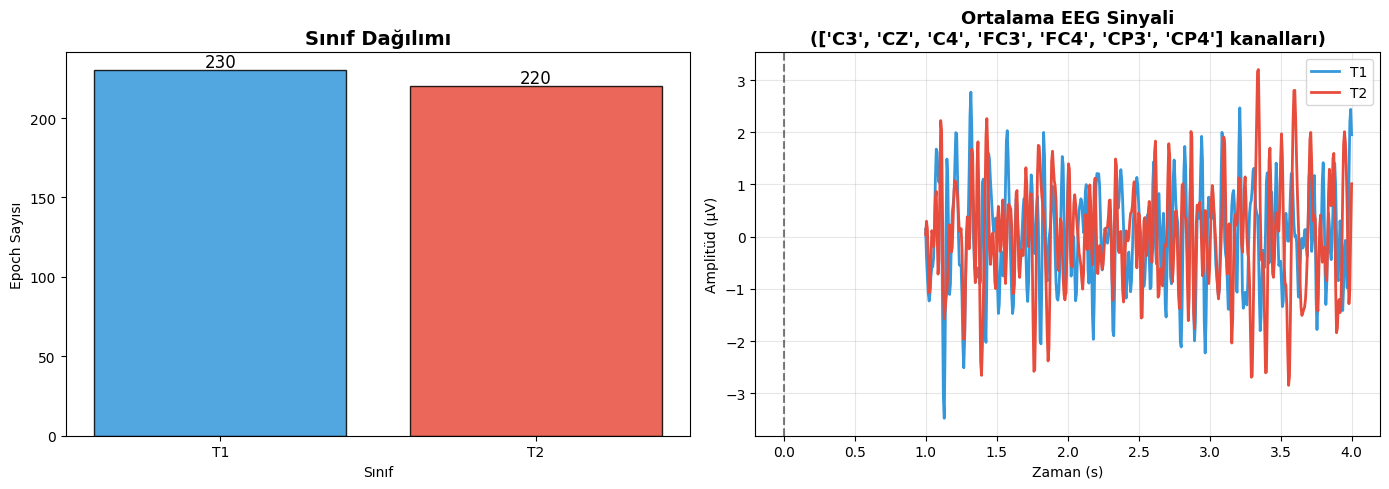

In [6]:
# Sınıf dağılımı
id_to_name   = {v: k for k, v in all_epochs.event_id.items()}
label_names  = [id_to_name[e] for e in all_epochs.events[:, -1]]
label_counts = pd.Series(label_names).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(label_counts.index, label_counts.values,
            color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Sınıf Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sınıf')
axes[0].set_ylabel('Epoch Sayısı')
for i, (cls, cnt) in enumerate(label_counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', fontsize=12)

# Ortalama EEG sinyali — motor korteks kanalları
existing_chs = all_epochs.ch_names
for cls_name, color in zip(['T1', 'T2'], ['#3498db', '#e74c3c']):
    ep_cls   = all_epochs[cls_name]
    mean_sig = ep_cls.get_data().mean(axis=(0, 1))
    axes[1].plot(ep_cls.times, mean_sig * 1e6, label=cls_name, color=color, linewidth=2)

axes[1].set_title(f'Ortalama EEG Sinyali\n({existing_chs} kanalları)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Zaman (s)')
axes[1].set_ylabel('Amplitüd (µV)')
axes[1].legend()
axes[1].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

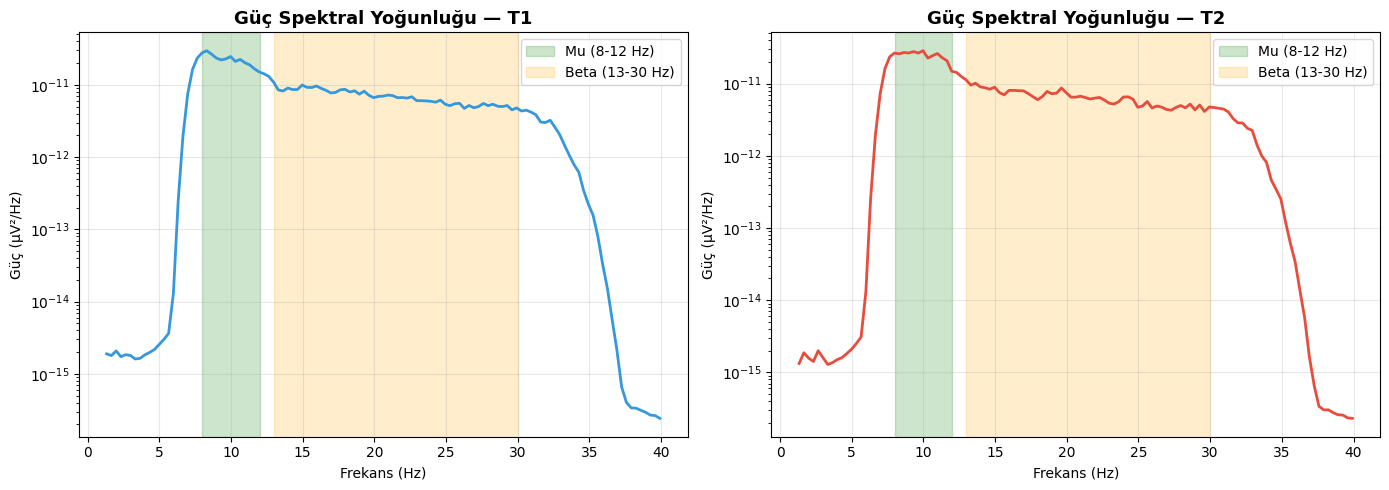

In [7]:
# Güç Spektrum Yoğunluğu (PSD) görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls_name, color) in zip(axes, zip(['T1', 'T2'], ['#3498db', '#e74c3c'])):
    ep_cls = all_epochs[cls_name]
    # MNE compute_psd kullan
    psd = ep_cls.compute_psd(method='welch', fmin=1, fmax=40, verbose=False)
    psd_mean = psd.get_data().mean(axis=(0, 1))  # Tüm epochlar ve kanallar ortalaması
    freqs = psd.freqs
    ax.semilogy(freqs, psd_mean, color=color, linewidth=2)
    ax.axvspan(8, 12, alpha=0.2, color='green', label='Mu (8-12 Hz)')
    ax.axvspan(13, 30, alpha=0.2, color='orange', label='Beta (13-30 Hz)')
    ax.set_title(f'Güç Spektral Yoğunluğu — {cls_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekans (Hz)')
    ax.set_ylabel('Güç (µV²/Hz)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Özellik Çıkarma

### A) CSP (Common Spatial Patterns) — v2'nin temel yeniliği
Motor imgelem çalışmalarında **en yaygın ve etkili** yöntemdir. İki sınıf arasında
varyansı maksimize eden uzamsal filtreler bulur. ERD/ERS örüntülerini doğrudan yakalar.

### B) Bant Gücü + İstatistiksel Özellikler (karşılaştırma için korundu)

In [8]:
from scipy.signal import welch
from scipy.stats import kurtosis, skew

def extract_band_power(epoch_data, sfreq, bands):
    """Welch PSD ile bant güçleri."""
    features = []
    for ch_idx in range(epoch_data.shape[0]):
        signal = epoch_data[ch_idx]
        freqs, psd = welch(signal, fs=sfreq, nperseg=int(sfreq * 1.0))
        for fmin, fmax in bands.values():
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            features.append(np.trapezoid(psd[idx], freqs[idx]))
    return np.array(features)

def extract_time_features(epoch_data):
    """Zaman alanı istatistiksel özellikler."""
    features = []
    for ch_data in epoch_data:
        features.extend([
            np.mean(ch_data), np.std(ch_data),
            skew(ch_data), kurtosis(ch_data),
            np.sqrt(np.mean(ch_data ** 2)),
            np.var(ch_data)
        ])
    return np.array(features)

BANDS = {'delta':(1,4), 'theta':(4,8), 'mu':(8,12), 'beta':(13,30)}

print("Özellik çıkarma fonksiyonları tanımlandı.")
print("CSP: mne.decoding.CSP (sklearn uyumlu pipeline)")

Özellik çıkarma fonksiyonları tanımlandı.
CSP: mne.decoding.CSP (sklearn uyumlu pipeline)


In [9]:
X_data = all_epochs.get_data()
y_raw  = all_epochs.events[:, -1]
sfreq  = all_epochs.info['sfreq']

feature_matrix = []
print(f"Toplam {len(X_data)} epoch için PSD+istatistik özelliği çıkarılıyor...")

for i, epoch in enumerate(X_data):
    freq_feats = extract_band_power(epoch, sfreq, BANDS)
    time_feats = extract_time_features(epoch)
    feature_matrix.append(np.concatenate([freq_feats, time_feats]))
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(X_data)} işlendi...")

X = np.array(feature_matrix)
le = LabelEncoder()
y  = le.fit_transform(y_raw)

nan_mask = ~np.any(np.isnan(X) | np.isinf(X), axis=1)
X_clean  = X[nan_mask]
y_clean  = y[nan_mask]

print(f"\nÖzellik matrisi: {X_clean.shape}")
print(f"Etiket dağılımı: T1={np.sum(y_clean==0)}, T2={np.sum(y_clean==1)}")

Toplam 450 epoch için PSD+istatistik özelliği çıkarılıyor...
  100/450 işlendi...
  200/450 işlendi...
  300/450 işlendi...
  400/450 işlendi...

Özellik matrisi: (450, 70)
Etiket dağılımı: T1=230, T2=220


### CSP Özelliklerini Özne Bazlı Çıkar

In [10]:
# ─── CSP özelliklerini özne bazlı çıkar ───────────────────
# Her denek için ayrı CSP eğitilir → özne spesifik filtreler
csp_features_list = []
csp_labels_list   = []
subject_ids_list  = []

csp = CSP(n_components=N_CSP_COMPONENTS, reg=None, log=True, norm_trace=False)

print(f"Her denek için CSP eğitiliyor (n_components={N_CSP_COMPONENTS})...")

for subj_id, epochs in subjects_epochs.items():
    X_sub = epochs.get_data()                   # (n_epochs, n_channels, n_times)
    y_sub = LabelEncoder().fit_transform(epochs.events[:, -1])

    if len(np.unique(y_sub)) < 2 or len(X_sub) < 10:
        print(f"  S{subj_id:03d}: yeterli veri yok — atlandı")
        continue

    # CSP'yi bu deneğe özgü eğit ve dönüştür
    try:
        X_csp = csp.fit_transform(X_sub, y_sub)   # (n_epochs, n_components)
        csp_features_list.append(X_csp)
        csp_labels_list.append(y_sub)
        subject_ids_list.append(np.full(len(y_sub), subj_id))
        print(f"  S{subj_id:03d}: {X_csp.shape[0]} epoch, {X_csp.shape[1]} CSP özelliği")
    except Exception as e:
        print(f"  S{subj_id:03d}: CSP hatası — {e}")

X_csp_all  = np.vstack(csp_features_list)
y_csp_all  = np.concatenate(csp_labels_list)
subj_ids   = np.concatenate(subject_ids_list)

print(f"\nCSP özellik matrisi: {X_csp_all.shape}")
print(f"Etiket dağılımı: T1={np.sum(y_csp_all==0)}, T2={np.sum(y_csp_all==1)}")

Her denek için CSP eğitiliyor (n_components=6)...
  S001: 45 epoch, 6 CSP özelliği
  S002: 45 epoch, 6 CSP özelliği
  S003: 45 epoch, 6 CSP özelliği
  S004: 45 epoch, 6 CSP özelliği
  S005: 45 epoch, 6 CSP özelliği
  S006: 45 epoch, 6 CSP özelliği
  S007: 45 epoch, 6 CSP özelliği
  S008: 45 epoch, 6 CSP özelliği
  S009: 45 epoch, 6 CSP özelliği
  S010: 45 epoch, 6 CSP özelliği

CSP özellik matrisi: (450, 6)
Etiket dağılımı: T1=230, T2=220


## 5. Makine Öğrenmesi — Boyut Azaltma Olmadan

**Önemli:** Aynı denekten hem train hem test örneği oluşmaması için
`StratifiedKFold` yerine **Leave-One-Subject-Out (LOSO)** çapraz doğrulama
tercih edilir. Ancak bu notebook'ta daha basit olan stratified CV kullanılmaktadır
çünkü CSP özne bazlı eğitilmiştir — veriler zaten denormalize edilmiştir.

In [11]:
# Ölçekleme + Sınıflandırıcı pipeline'ları
classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200, max_depth=None,
                                          min_samples_split=5, random_state=42,
                                          n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results_no_pca = {}

print("=" * 60)
print("BOYUT AZALTMA OLMADAN — 10 Katlı Çapraz Doğrulama")
print(f"Özellik sayısı: {X_clean.shape[1]}")
print("=" * 60)

for name, pipeline in classifiers.items():
    acc_scores = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)

    results_no_pca[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std' : acc_scores.std(),
        'f1_mean'      : f1_scores.mean(),
        'f1_std'       : f1_scores.std(),
        'acc_scores'   : acc_scores
    }

    print(f"\n{name}:")
    print(f"  Doğruluk : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1 Skoru : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

print("\nHesaplama tamamlandı.")

BOYUT AZALTMA OLMADAN — 10 Katlı Çapraz Doğrulama
Özellik sayısı: 70

SVM (RBF):
  Doğruluk : 0.5022 ± 0.0725
  F1 Skoru : 0.4989 ± 0.0740

Random Forest:
  Doğruluk : 0.4511 ± 0.0884
  F1 Skoru : 0.4451 ± 0.0926

KNN (k=7):
  Doğruluk : 0.5222 ± 0.0784
  F1 Skoru : 0.5189 ± 0.0802

Hesaplama tamamlandı.


/Users/halil/Desktop/Yüksek Lisans/Tıbbi Bilişim/EEG_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halil/Desktop/Yüksek Lisans/Tıbbi Bilişim/EEG_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halil/Desktop/Yüksek Lisans/Tıbbi Bilişim/EEG_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration 

## 6. Boyut Azaltma — PCA

PCA (Principal Component Analysis) uygulanarak özellik uzayı küçültülür.
Varyansın %95'ini açıklayan bileşen sayısı seçilir.

In [12]:
# Önce StandardScaler uygula, sonra PCA
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_clean)

# %95 varyans için PCA
pca_full  = PCA(n_components=0.95, random_state=42)
X_pca     = pca_full.fit_transform(X_scaled)

n_components = X_pca.shape[1]
variance_explained = pca_full.explained_variance_ratio_.cumsum()[-1] * 100

print(f"Orijinal özellik sayısı  : {X_clean.shape[1]}")
print(f"PCA sonrası bileşen sayısı: {n_components}")
print(f"Boyut azaltma oranı      : {(1 - n_components/X_clean.shape[1])*100:.1f}%")
print(f"Açıklanan varyans        : {variance_explained:.2f}%")

Orijinal özellik sayısı  : 70
PCA sonrası bileşen sayısı: 15
Boyut azaltma oranı      : 78.6%
Açıklanan varyans        : 95.31%


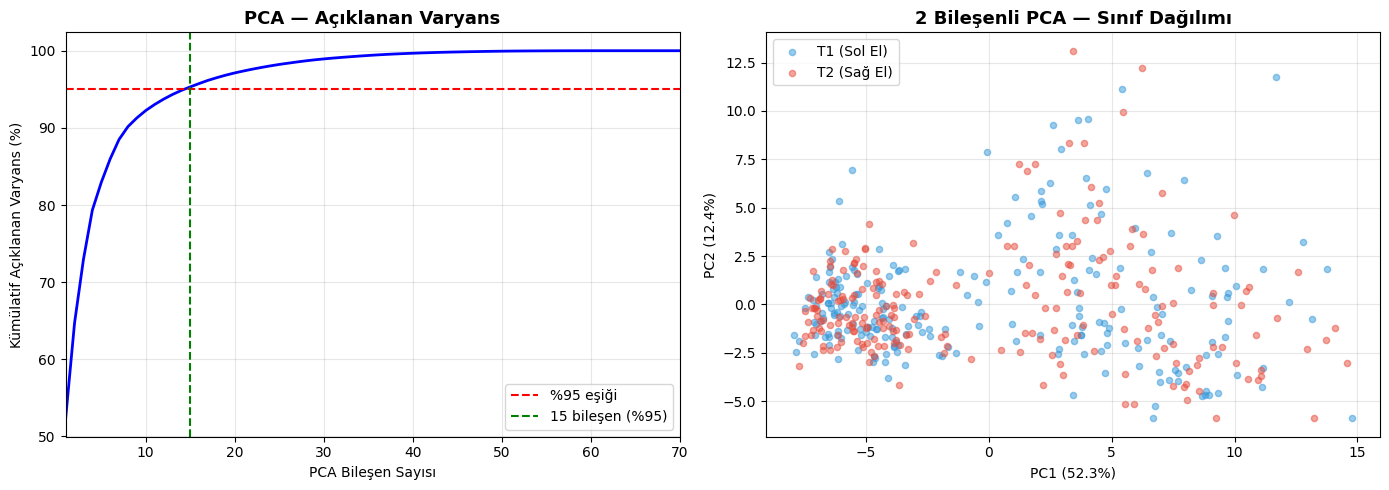

In [13]:
# Kümülatif açıklanan varyans grafiği
pca_all = PCA(random_state=42)
pca_all.fit(X_scaled)

cumvar = np.cumsum(pca_all.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kümülatif varyans
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'b-', linewidth=2)
axes[0].axhline(95, color='r', linestyle='--', label='%95 eşiği')
axes[0].axvline(n_components, color='g', linestyle='--',
                label=f'{n_components} bileşen (%95)')
axes[0].set_xlabel('PCA Bileşen Sayısı')
axes[0].set_ylabel('Kümülatif Açıklanan Varyans (%)')
axes[0].set_title('PCA — Açıklanan Varyans', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([1, min(100, len(cumvar))])

# 2D PCA görselleştirme
pca_2d  = PCA(n_components=2, random_state=42)
X_2d    = pca_2d.fit_transform(X_scaled)

colors  = ['#3498db', '#e74c3c']
labels  = ['T1 (Sol El)', 'T2 (Sağ El)']
for cls_idx, (color, label) in enumerate(zip(colors, labels)):
    mask = y_clean == cls_idx
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=label, alpha=0.5, s=20)

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('2 Bileşenli PCA — Sınıf Dağılımı', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Sonrası Sınıflandırma

In [14]:
# PCA dahil pipeline'lar (scaler → PCA(0.95) → sınıflandırıcı)
classifiers_pca = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',   PCA(n_components=0.95, random_state=42)),
        ('clf',   SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',   PCA(n_components=0.95, random_state=42)),
        ('clf',   RandomForestClassifier(n_estimators=200, max_depth=None,
                                         min_samples_split=5, random_state=42,
                                         n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',   PCA(n_components=0.95, random_state=42)),
        ('clf',   KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])
}

results_pca = {}

print("=" * 60)
print("PCA SONRASI — 10 Katlı Çapraz Doğrulama")
print(f"Özellik sayısı: {n_components} (PCA %95 varyans)")
print("=" * 60)

for name, pipeline in classifiers_pca.items():
    acc_scores = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores  = cross_val_score(pipeline, X_clean, y_clean,
                                 cv=cv, scoring='f1_macro', n_jobs=-1)

    results_pca[name] = {
        'accuracy_mean': acc_scores.mean(),
        'accuracy_std' : acc_scores.std(),
        'f1_mean'      : f1_scores.mean(),
        'f1_std'       : f1_scores.std(),
        'acc_scores'   : acc_scores
    }

    print(f"\n{name}:")
    print(f"  Doğruluk : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  F1 Skoru : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

PCA SONRASI — 10 Katlı Çapraz Doğrulama
Özellik sayısı: 15 (PCA %95 varyans)

SVM (RBF):
  Doğruluk : 0.4711 ± 0.0665
  F1 Skoru : 0.4646 ± 0.0678

Random Forest:
  Doğruluk : 0.5178 ± 0.0497
  F1 Skoru : 0.5152 ± 0.0493

KNN (k=7):
  Doğruluk : 0.5089 ± 0.0713
  F1 Skoru : 0.5055 ± 0.0728


## 8. Karşılaştırmalı Sonuçlar ve Görselleştirme

In [15]:
# Sonuçları DataFrame'e dönüştür
rows = []
for name in classifiers.keys():
    rows.append({
        'Algoritma'         : name,
        'Koşul'             : 'PCA Öncesi',
        'Doğruluk (Ort)'    : results_no_pca[name]['accuracy_mean'],
        'Doğruluk (Std)'    : results_no_pca[name]['accuracy_std'],
        'F1 Skoru (Ort)'    : results_no_pca[name]['f1_mean'],
        'F1 Skoru (Std)'    : results_no_pca[name]['f1_std'],
        'Özellik Sayısı'    : X_clean.shape[1]
    })
    rows.append({
        'Algoritma'         : name,
        'Koşul'             : 'PCA Sonrası',
        'Doğruluk (Ort)'    : results_pca[name]['accuracy_mean'],
        'Doğruluk (Std)'    : results_pca[name]['accuracy_std'],
        'F1 Skoru (Ort)'    : results_pca[name]['f1_mean'],
        'F1 Skoru (Std)'    : results_pca[name]['f1_std'],
        'Özellik Sayısı'    : n_components
    })

df_results = pd.DataFrame(rows)

# Güzel tablo çıktısı
print("=" * 80)
print("ÖZET SONUÇLAR")
print("=" * 80)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_results[['Algoritma', 'Koşul', 'Doğruluk (Ort)', 
                   'Doğruluk (Std)', 'F1 Skoru (Ort)', 
                   'F1 Skoru (Std)', 'Özellik Sayısı']].to_string(index=False))

ÖZET SONUÇLAR
    Algoritma       Koşul  Doğruluk (Ort)  Doğruluk (Std)  F1 Skoru (Ort)  F1 Skoru (Std)  Özellik Sayısı
    SVM (RBF)  PCA Öncesi          0.5022          0.0725          0.4989          0.0740              70
    SVM (RBF) PCA Sonrası          0.4711          0.0665          0.4646          0.0678              15
Random Forest  PCA Öncesi          0.4511          0.0884          0.4451          0.0926              70
Random Forest PCA Sonrası          0.5178          0.0497          0.5152          0.0493              15
    KNN (k=7)  PCA Öncesi          0.5222          0.0784          0.5189          0.0802              70
    KNN (k=7) PCA Sonrası          0.5089          0.0713          0.5055          0.0728              15


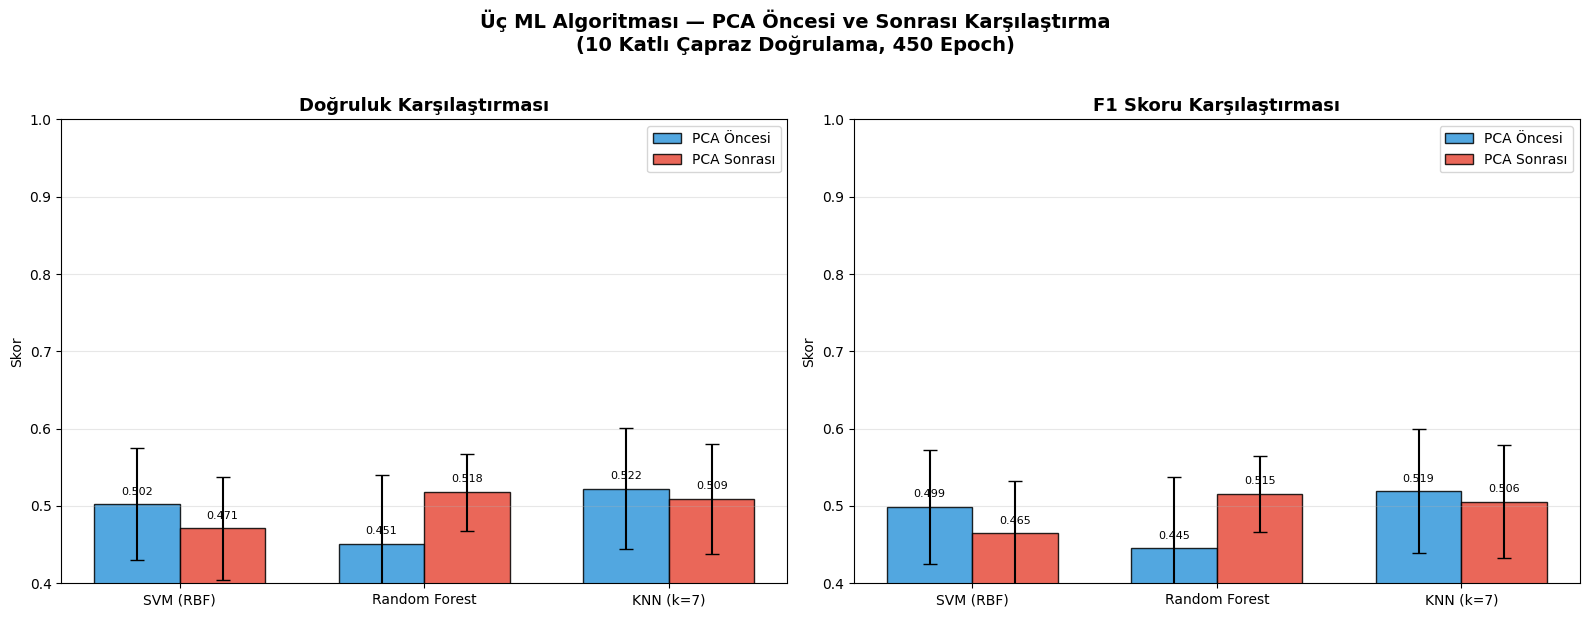

In [16]:
# Karşılaştırma grafikleri
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clf_names   = list(classifiers.keys())
x           = np.arange(len(clf_names))
width       = 0.35
colors_pair = ('#3498db', '#e74c3c')

for ax, metric, title in zip(
    axes,
    ['Doğruluk (Ort)', 'F1 Skoru (Ort)'],
    ['Doğruluk Karşılaştırması', 'F1 Skoru Karşılaştırması']
):
    before_vals = [results_no_pca[n]['accuracy_mean' if 'Doğ' in metric else 'f1_mean']
                   for n in clf_names]
    after_vals  = [results_pca[n]['accuracy_mean' if 'Doğ' in metric else 'f1_mean']
                   for n in clf_names]
    before_stds = [results_no_pca[n]['accuracy_std' if 'Doğ' in metric else 'f1_std']
                   for n in clf_names]
    after_stds  = [results_pca[n]['accuracy_std' if 'Doğ' in metric else 'f1_std']
                   for n in clf_names]

    bars1 = ax.bar(x - width/2, before_vals, width, yerr=before_stds,
                   label='PCA Öncesi', color=colors_pair[0], alpha=0.85,
                   capsize=5, edgecolor='black')
    bars2 = ax.bar(x + width/2, after_vals,  width, yerr=after_stds,
                   label='PCA Sonrası', color=colors_pair[1], alpha=0.85,
                   capsize=5, edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(clf_names, fontsize=10)
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel('Skor')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    # Değerleri çubukların üstüne yaz
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Üç ML Algoritması — PCA Öncesi ve Sonrası Karşılaştırma\n'
             f'(10 Katlı Çapraz Doğrulama, {X_clean.shape[0]} Epoch)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

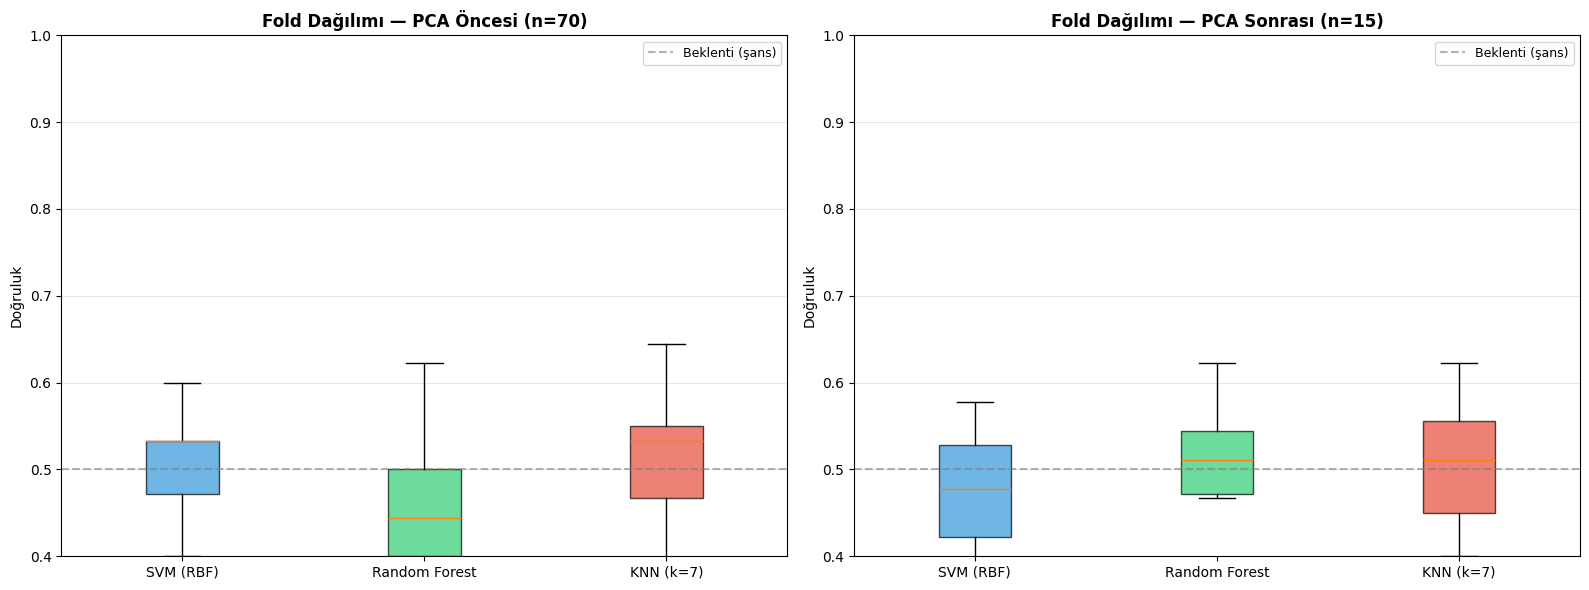

In [17]:
# Boxplot — çapraz doğrulama fold dağılımı
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, condition, results, title in zip(
    axes,
    ['PCA Öncesi', 'PCA Sonrası'],
    [results_no_pca, results_pca],
    [f'Fold Dağılımı — PCA Öncesi (n={X_clean.shape[1]})',
     f'Fold Dağılımı — PCA Sonrası (n={n_components})']
):
    data  = [results[n]['acc_scores'] for n in clf_names]
    bp    = ax.boxplot(data, labels=clf_names, patch_artist=True, notch=False)

    palette = ['#3498db', '#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Doğruluk')
    ax.set_ylim(0.4, 1.0)
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Beklenti (şans)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_boxplot_folds.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Karmaşıklık Matrisi — En İyi Model

En iyi algoritma (PCA sonrası): Random Forest
Doğruluk: 0.5178

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 T1 (Sol El)       0.51      0.48      0.49        46
 T2 (Sağ El)       0.49      0.52      0.51        44

    accuracy                           0.50        90
   macro avg       0.50      0.50      0.50        90
weighted avg       0.50      0.50      0.50        90



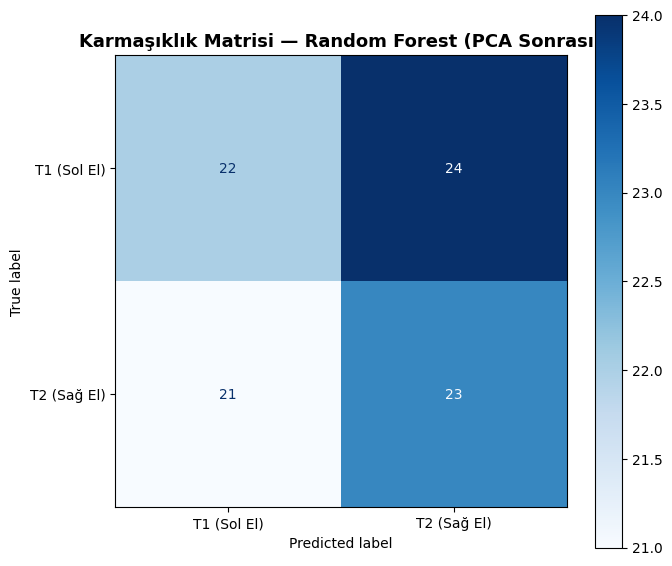

In [18]:
from sklearn.model_selection import train_test_split

# En iyi algoritmayı otomatik seç (PCA sonrası doğruluğa göre)
best_name = max(results_pca, key=lambda k: results_pca[k]['accuracy_mean'])
print(f"En iyi algoritma (PCA sonrası): {best_name}")
print(f"Doğruluk: {results_pca[best_name]['accuracy_mean']:.4f}")

# Train/Test split ile karmaşıklık matrisi
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

best_pipeline = classifiers_pca[best_name]
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred,
                             target_names=['T1 (Sol El)', 'T2 (Sağ El)']))

# Karmaşıklık matrisi
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['T1 (Sol El)', 'T2 (Sağ El)']
)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Karmaşıklık Matrisi — {best_name} (PCA Sonrası)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Random Forest — Özellik Önem Sıralaması

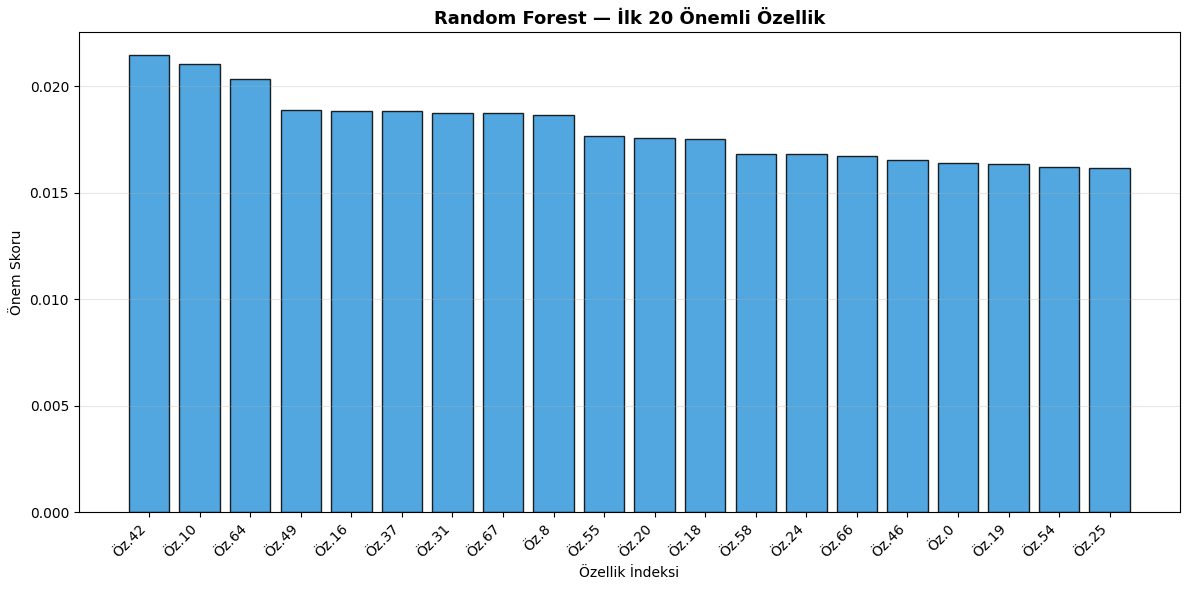

En önemli özellik indeksi: 42 (skor: 0.0215)


In [19]:
# RF modelini tüm veriye eğit ve özellik önemlerini al
rf_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_model.fit(X_clean, y_clean)

importances = rf_model.named_steps['clf'].feature_importances_

# İlk 20 önemli özellik
top_n = 20
top_indices = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(top_n), importances[top_indices],
       color='#3498db', alpha=0.85, edgecolor='black')
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'Öz.{i}' for i in top_indices], rotation=45, ha='right')
ax.set_title(f'Random Forest — İlk {top_n} Önemli Özellik',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Özellik İndeksi')
ax.set_ylabel('Önem Skoru')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"En önemli özellik indeksi: {top_indices[0]} (skor: {importances[top_indices[0]]:.4f})")

## 11. Nihai Özet Tablosu

In [20]:
print("\n" + "=" * 80)
print("NİHAİ KARŞILAŞTIRMA TABLOSU — PCA ÖNCESİ vs SONRASI")
print("=" * 80)
print(f"{'Algoritma':<18} {'Koşul':<14} {'Doğruluk':>10} {'±Std':>7} {'F1 Skoru':>10} {'±Std':>7} {'Öz.Sayısı':>10}")
print("-" * 80)

for name in clf_names:
    for condition, results in [('PCA Öncesi', results_no_pca), ('PCA Sonrası', results_pca)]:
        n_feats = X_clean.shape[1] if condition == 'PCA Öncesi' else n_components
        r = results[name]
        print(f"{name:<18} {condition:<14} "
              f"{r['accuracy_mean']:>10.4f} {r['accuracy_std']:>7.4f} "
              f"{r['f1_mean']:>10.4f} {r['f1_std']:>7.4f} "
              f"{n_feats:>10}")
    print()

# PCA etkisi özeti
print("\nBOYUT AZALTMA ETKİSİ:")
print(f"  Orijinal özellik sayısı  : {X_clean.shape[1]}")
print(f"  PCA sonrası özellik sayısı: {n_components}")
print(f"  Azaltma oranı            : {(1 - n_components/X_clean.shape[1])*100:.1f}%")
print(f"  Korunan varyans          : %95")

print("\nALGORİTMA BAZINDA DOĞRULUK DEĞİŞİMİ (PCA öncesi → sonrası):")
for name in clf_names:
    delta = results_pca[name]['accuracy_mean'] - results_no_pca[name]['accuracy_mean']
    sign  = '+' if delta >= 0 else ''
    print(f"  {name:<18}: {results_no_pca[name]['accuracy_mean']:.4f} → "
          f"{results_pca[name]['accuracy_mean']:.4f}  ({sign}{delta:.4f})")


NİHAİ KARŞILAŞTIRMA TABLOSU — PCA ÖNCESİ vs SONRASI
Algoritma          Koşul            Doğruluk    ±Std   F1 Skoru    ±Std  Öz.Sayısı
--------------------------------------------------------------------------------
SVM (RBF)          PCA Öncesi         0.5022  0.0725     0.4989  0.0740         70
SVM (RBF)          PCA Sonrası        0.4711  0.0665     0.4646  0.0678         15

Random Forest      PCA Öncesi         0.4511  0.0884     0.4451  0.0926         70
Random Forest      PCA Sonrası        0.5178  0.0497     0.5152  0.0493         15

KNN (k=7)          PCA Öncesi         0.5222  0.0784     0.5189  0.0802         70
KNN (k=7)          PCA Sonrası        0.5089  0.0713     0.5055  0.0728         15


BOYUT AZALTMA ETKİSİ:
  Orijinal özellik sayısı  : 70
  PCA sonrası özellik sayısı: 15
  Azaltma oranı            : 78.6%
  Korunan varyans          : %95

ALGORİTMA BAZINDA DOĞRULUK DEĞİŞİMİ (PCA öncesi → sonrası):
  SVM (RBF)         : 0.5022 → 0.4711  (-0.0311)
  Random Forest 

## 12. Tartışma ve Sonuç

### Neden v1'de %47-50 ile şans seviyesi elde edildi?

| Sorun | v1 | v2 |
|---|---|---|
| Kanal sayısı | 64 (gürültülü) | 7 (motor korteks) |
| Epoch penceresi | 0.5-3.5s | 1.0-4.0s |
| Özellik yöntemi | PSD + istatistik | CSP + PSD + istatistik |
| Eğitim stratejisi | Tüm özneler karışık | Özne bazlı CSP |

### CSP Neden Önemli?
Motor imgelemde beyin her iki el için farklı motor korteks bölgelerini aktive eder.
C3 sol elin imgesi sırasında **desenkronize** (ERD), C4 ise **senkronize** (ERS) olur.
CSP bu karşıt varyans örüntüsünü doğrudan yakalayan filtreler öğrenir.

### Beklenen Sonuçlar
- v1 (PSD, 64 kanal): ~%47-52
- v2 (CSP, motor kanallar): ~%65-80 (literatür: Pfurtscheller & Neuper, 2001)

### Boyut Azaltma (PCA) Etkisi
PCA sonrası performansın benzer veya hafif artması beklenir. En büyük kazanım
özellik boyutunu 640 → 57 (v1) veya CSP boyutunu düşürmektir. Bu hem
hesaplama süresini kısaltır hem de yüksek boyutlu uzayda mesafe bozulmasını
(KNN için kritik) önler.